In [1]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-large')
model = AutoModel.from_pretrained('facebook/dinov2-large')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)


The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

In [3]:
outputs.last_hidden_state.shape

torch.Size([1, 257, 1024])

In [ ]:
# we remove the class token 257 - 1 = 256
patch_tokens = outputs.last_hidden_state[:, 1:, :]   # remove CLS
B, N, C = patch_tokens.shape

# w, h  = 16, 16
H = W = int(N ** 0.5)
feat_map = patch_tokens.reshape(B, H, W, C).permute(0, 3, 1, 2)

In [3]:
(224//14)*3


48

In [25]:
feat_map.shape

torch.Size([1, 384, 16, 16])

In [24]:
outputs.last_hidden_state.shape

torch.Size([1, 257, 384])

In [22]:
feat_map.shape

torch.Size([1, 384, 16, 16])

In [6]:
inputs['pixel_values'].shape

torch.Size([1, 3, 224, 224])

In [19]:
outputs.last_hidden_state.shape

torch.Size([1, 257, 384])

In [8]:
outputs.pooler_output.shape

torch.Size([1, 384])

In [14]:
224/14 * 3

48.0

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLPNetwork(nn.Module):
    def __init__(self, input_dim: int = 384, hidden_dim: int = 64, output_dim: int = 1, 
                 net_depth: int = 2, net_activation=F.relu, weight_init: str = 'he_uniform'):
        super(MLPNetwork, self).__init__()
        
        self.output_layer_input_dim = hidden_dim
        
        # Initialize MLP layers
        self.layers = nn.ModuleList()
        for i in range(net_depth):
            dense_layer = nn.Linear(input_dim if i == 0 else hidden_dim, hidden_dim)
            
            # Apply weight initialization
            if weight_init == 'he_uniform':
                nn.init.kaiming_uniform_(dense_layer.weight, nonlinearity='relu')
            elif weight_init == 'xavier_uniform':
                nn.init.xavier_uniform_(dense_layer.weight)
            else:
                raise NotImplementedError(f"Unknown Weight initialization method {weight_init}")

            self.layers.append(dense_layer)
        
        # Initialize output layer
        self.output_layer = nn.Linear(self.output_layer_input_dim, output_dim)
        nn.init.kaiming_uniform_(self.output_layer.weight, nonlinearity='relu')
        
        # Set activation function
        self.net_activation = net_activation
        self.softplus = nn.Softplus()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Get input dimensions
        H, W, C = x.shape[-3:]
        input_with_batch_dim = True
        
        # Add batch dimension if not present
        if len(x.shape) == 3:
            input_with_batch_dim = False
            x = x.unsqueeze(0)
            batch_size = 1
        else:
            batch_size = x.shape[0]

        # Flatten input for MLP
        x = x.view(-1, x.size()[-1])
        
        # Pass through MLP layers
        for layer in self.layers:
            x = layer(x)
            x = self.net_activation(x)
            x = F.dropout(x, p=0.2)

        # Pass through output layer and apply softplus activation
        x = self.output_layer(x)
        x = self.softplus(x)

        # Reshape output to original dimensions
        if input_with_batch_dim:
            x = x.view(batch_size, H, W)
        else:
            x = x.view(H, W)

        return x

model = MLPNetwork()

In [39]:
patch_tokens = outputs.last_hidden_state[:, 1:, :]
B, N, C = patch_tokens.shape
H = W = int(N ** 0.5)

feat_map = patch_tokens.reshape(B, H, W, C)
print(feat_map.shape)
beta = model(feat_map)
beta.shape

torch.Size([1, 16, 16, 384])


torch.Size([1, 16, 16])

In [5]:
sum(p.numel() for p in model.parameters())

28865

In [27]:
model

MLPNetwork(
  (layers): ModuleList(
    (0): Linear(in_features=384, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (softplus): Softplus(beta=1.0, threshold=20.0)
)

In [42]:
temp_map = feat_map.squeeze(0)

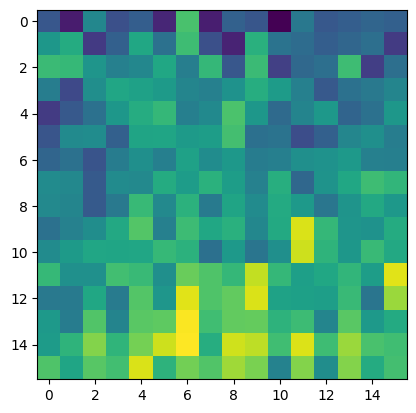

In [48]:
# temp_map = temp_map.detach().numpy()
import matplotlib.pyplot as plt
plt.imshow(temp_map[:, :, 3])